<a href="https://colab.research.google.com/github/SlepenkovaDaria/My-homework/blob/main/ThirdDZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem 1


Implement serial test and apply to a `samples`

In [ ]:
import numpy as np
import scipy.stats as stats

def rng(m = 2 ** 32, a = 1103515245, c = 12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

def serial_test(samples, k = 10, min_expected = 5):
    expected = (len(samples) // 2) / (k * k)

    if expected < min_expected:
        raise ValueError(f"Need more samples or smaller k!")

    pairs = [(samples[2 * i], samples[2 * i + 1]) for i in range(len(samples) // 2)]
    observed = np.zeros((k, k), dtype = int)
    for u, v in pairs:
        i = int(u * k)
        j = int(v * k)
        if i == k:
            i = k - 1
        if j == k:
            j = k - 1
        observed[i, j] += 1

    f_obs = observed.reshape(-1)
    f_exp = np.full(k * k, expected)
    result = stats.chisquare(f_obs, f_exp)
    return result

rng.current = 1
samples = [rng() for _ in range(1000)]
result = serial_test(samples, 10)
print(f"Statistic: {result.statistic}, p-value: {result.pvalue}")
if result.pvalue < 0.05:
    print("Reject H0: distribution is not uniform")
else:
    print("Do not reject H0: no evidence against uniform distribution")

Statistic: 114.39999999999999, p-value: 0.1380441495447643
Do not reject H0: no evidence against uniform distribution


# Problem 2*

Implement permutation test and apply to a `samples`

In [ ]:
import numpy as np
import scipy.stats as stats
from itertools import permutations

def rng(m = 2 ** 32, a = 1103515245, c = 12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

def permutation_test(samples, d = 3, min_expected = 5):
    n = len(samples) // d
    all_permutations = list(permutations(range(d)))
    expected = n / len(all_permutations)

    if expected < min_expected:
        raise ValueError(f"Need more samples or smaller d!")

    if n * d != len(samples):
        print(f"The last {len(samples) - n * d} elements were discarded")
        samples = samples[: n * d]

    series = [samples[i * d : (i + 1) * d] for i in range(n)]

    observed = {}
    for s in series:
        ranks = tuple(np.argsort(s))
        if ranks in observed:
            observed[ranks] += 1
        else:
            observed[ranks] = 1

    observed_array = []
    for perm in all_permutations:
        observed_array.append(observed.get(perm, 0))

    f_obs = np.array(observed_array)
    f_exp = np.full(len(all_permutations), expected)
    res = stats.chisquare(f_obs, f_exp)
    return res

rng.current = 1
samples = [rng() for _ in range(1000)]
result = permutation_test(samples, 3)
print(f"Statistic: {result.statistic}, p-value: {result.pvalue}")
if result.pvalue < 0.05:
    print("Reject H0: distribution is not uniform")
else:
    print("Do not reject H0: no evidence against uniform distribution")


The last 1 elements were discarded
Statistic: 4.8558558558558556, p-value: 0.4337239950364654
Do not reject H0: no evidence against uniform distribution


# Problem 3


Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [ ]:
import numpy as np
import scipy.stats as stats

def rng_bad(m = 2 ** 31, a = 65539, c = 0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

def rng_good(m = 2 ** 32, a = 1103515245, c = 12345):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m

def serial_test_3D(sample, k = 12, min_expected = 5):
    expected = (len(sample) // 3) / (k * k * k)

    if expected < min_expected:
        raise ValueError(f"Need more samples or smaller k!")

    triples = [(sample[3 * i], sample[3 * i + 1], sample[3 * i + 2]) for i
               in range(len(sample) // 3)]

    observed = np.zeros((k, k, k), dtype = int)

    for x, y, z, in triples:
        i = int(x * k)
        j = int(y * k)
        l = int(z * k)
        if i == k: i = k - 1
        if j == k: j = k - 1
        if l == k: l = k - 1
        observed[i, j, l] += 1

    f_obs = observed.reshape(-1)
    f_exp = np.full(k * k * k, expected)
    result = stats.chisquare(f_obs, f_exp)
    return result

rng_bad.current = 1
rng_good.current = 1
bad_samples = [rng_bad() for _ in range(30000)]
good_samples = [rng_good() for _ in range(30000)]
result_bad = serial_test_3D(bad_samples, 12)
result_good = serial_test_3D(good_samples, 12)
print(f"For bad RNG: statistic: {result_bad.statistic}, p-value: {result_bad.pvalue}, "
      f"uniform distribution: {result_bad.pvalue > 0.05}")
print(f"For good RNG: statistic: {result_good.statistic}, p-value: {result_good.pvalue}, "
      f"uniform distribution: {result_good.pvalue > 0.05}")


For bad RNG: statistic: 2398.3999999999996, p-value: 8.058511637780739e-25, uniform distribution: False
For good RNG: statistic: 1643.6096, p-value: 0.9237882775997049, uniform distribution: True


# Problem 4


Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

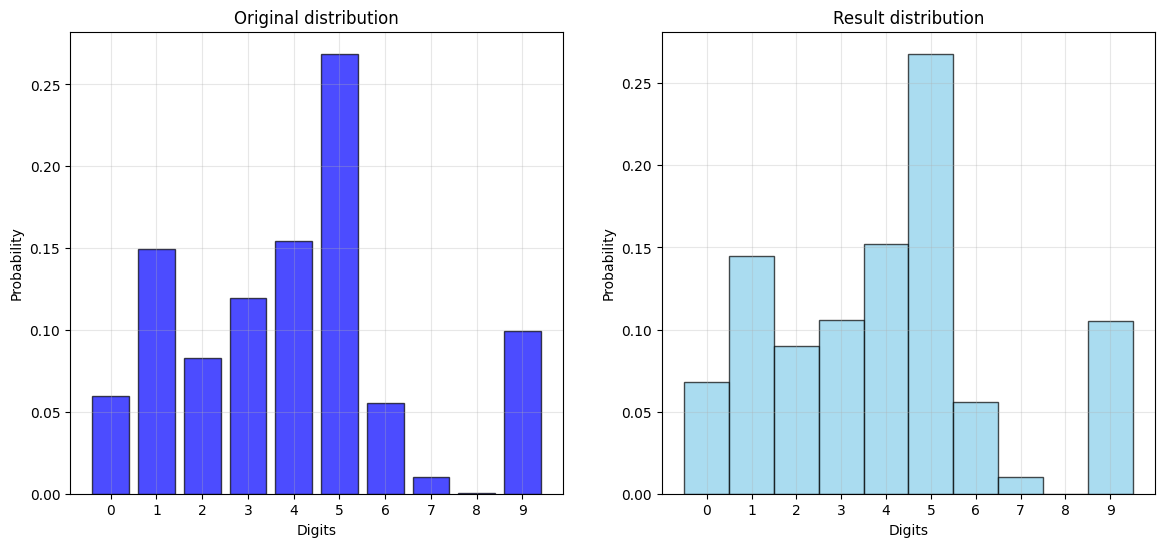

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rng(m = 2 ** 32, a = 1103515245, c = 12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

digits = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
weights = weights / weights.sum()

pairs = list(zip(weights, digits))
pairs.sort(reverse = True)
sorted_weights = np.array([elem[0] for elem in pairs])
sorted_digits = np.array([elem[1] for elem in pairs])
cum_sum = np.cumsum(sorted_weights)

random_values = [rng() for _ in range(1000)]
samples = []

for value in random_values:
    for i, cum in enumerate(cum_sum):
        if value < cum:
            samples.append(sorted_digits[i])
            break
samples = np.array(samples)

plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(digits, weights, alpha = 0.7, color = "blue", edgecolor = "black")
plt.xlabel("Digits")
plt.ylabel("Probability")
plt.title("Original distribution")
plt.xticks(digits)
plt.grid(True, alpha = 0.3)

plt.subplot(1, 2, 2)
plt.hist(samples, bins = np.arange(-0.5, 10.5, 1), density = True,
         alpha = 0.7, color = "skyblue", edgecolor = "black")
plt.xlabel("Digits")
plt.ylabel("Probability")
plt.title("Result distribution")
plt.xticks(digits)
plt.grid(True, alpha = 0.3)

plt.show()

# Problem 5

Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

Enter the value of the lambda parameter: 1


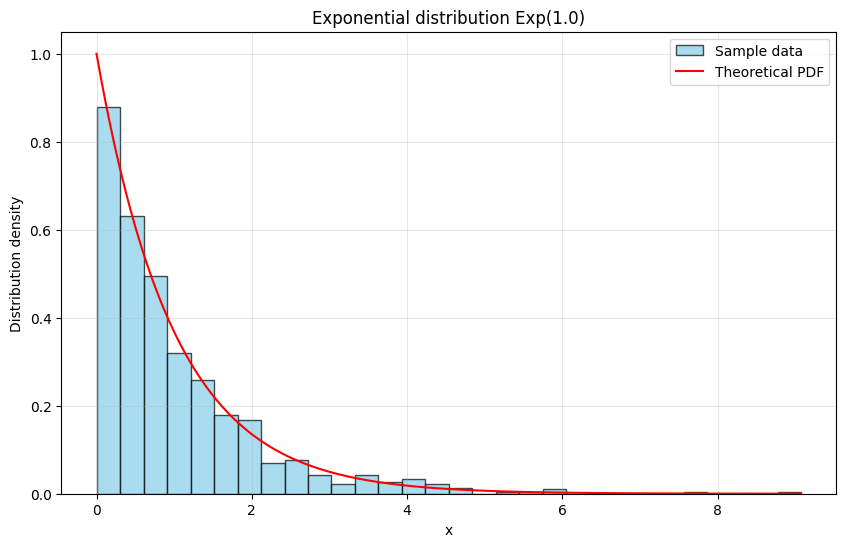

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

try:
    param = float(input("Enter the value of the lambda parameter: "))
    if param <= 0:
        print("Error: lambda must be greater than 0!")
        exit()
except ValueError:
    print("Error: please enter a valid number!")
    exit()

np.random.seed(1)
random_values = np.random.rand(1000)
our_values = -np.log(random_values) / param

plt.figure(figsize = (10, 6))
plt.hist(our_values, bins = 30, density = True, alpha = 0.7,
         color = "skyblue", edgecolor = "black", label = "Sample data")

x = np.linspace(0, np.max(our_values), 1000)
y= param * np.exp(-param * x)
plt.plot(x, y, "r-", label = "Theoretical PDF")

plt.xlabel("x")
plt.ylabel("Distribution density")
plt.title(f"Exponential distribution Exp({param})")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

# Problem 6

Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}.$$ Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

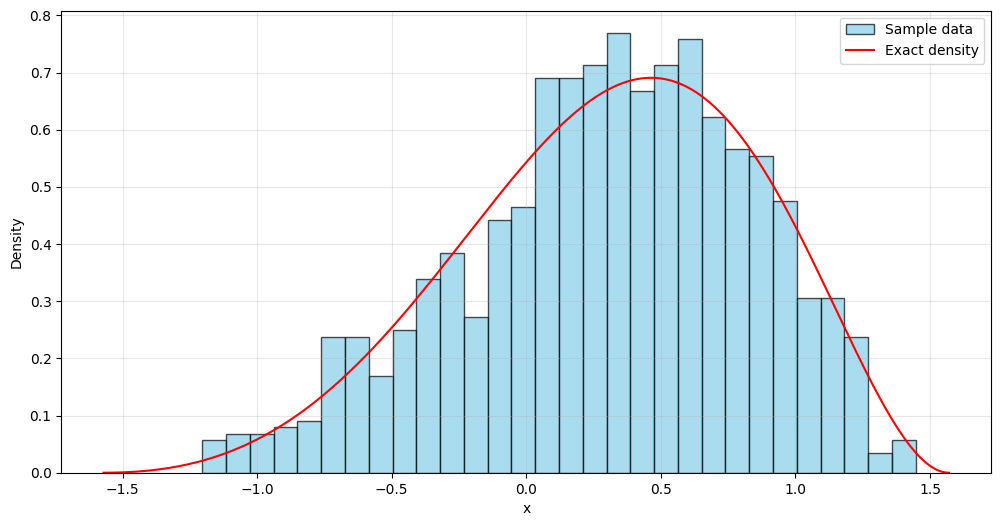

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

a, b = -np.pi / 2, np.pi / 2
target = lambda x: np.exp(x) * (np.cos(x) ** 2)
res = minimize_scalar(lambda x: -target(x), bounds = (a, b), method = "bounded")
f_max = target(res.x)

norm = (2 * np.exp(np.pi) - 2) / (5 * np.exp(np.pi / 2))
target_norm = lambda x: target(x) / norm

def rejection_sampling(n, seed = 1):
    np.random.seed(seed)
    samples = []

    while len(samples) < n:
        x = np.random.uniform(a, b)
        y = np.random.uniform(0, f_max)
        f_x = target(x)
        if y <= f_x:
            samples.append(x)

    return np.array(samples)

samples = rejection_sampling(1000, seed = 1)

plt.figure(figsize=(12, 6))
plt.hist(samples, bins = 30, density = True, alpha = 0.7, color = "skyblue", edgecolor = "black",
         label = "Sample data")

x_plot = np.linspace(a, b, 1000)
plt.plot(x_plot, target_norm(x_plot), "r-", label = "Exact density")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()


# Problem 7

Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

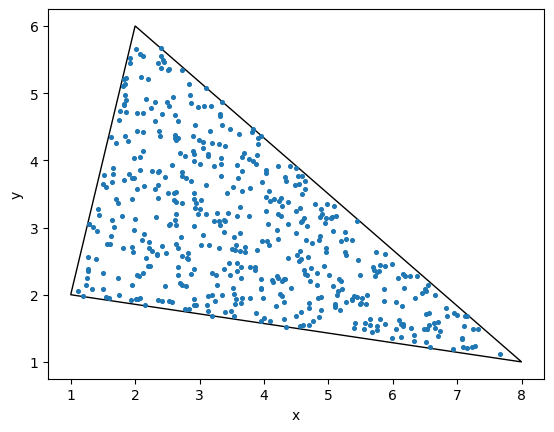

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

def sample_triangle_reflection(n, seed = 1):
    np.random.seed(seed)
    u = np.random.rand(n)
    v = np.random.rand(n)

    mask = (u + v > 1)
    u[mask] = 1 - u[mask]
    v[mask] = 1 - v[mask]
    points = A + u.reshape(-1, 1) * (B - A) + v.reshape(-1, 1) * (C - A)
    return points

samples = sample_triangle_reflection(500, seed = 1)

fig, ax = plt.subplots()
triangle = Polygon([A, B, C], closed = True, fill = False, edgecolor = "black")
ax.add_patch(triangle)
ax.scatter(samples[:, 0], samples[:, 1], s = 7)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

# Problem 8

Model without using the selection method a sample of  500  points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

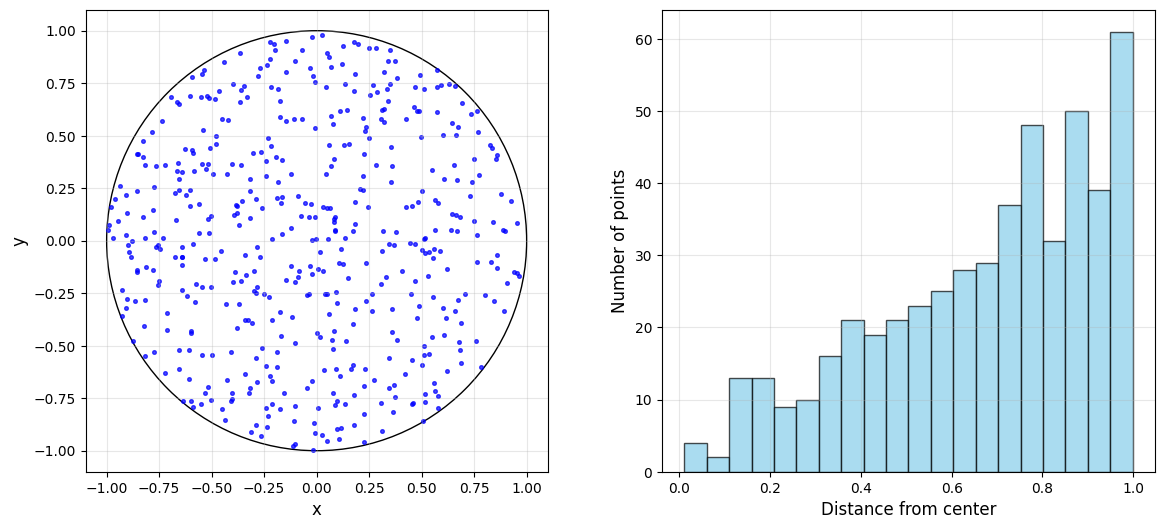

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sample_circle(n, seed = 1):
    np.random.seed(seed)
    r_squared = np.random.rand(n)
    theta = 2 * np.pi * np.random.rand(n)

    r = np.sqrt(r_squared)
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.column_stack((x, y))

samples = sample_circle(500, seed = 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))
circle = plt.Circle((0, 0), 1, fill = False, edgecolor = "black")
ax1.add_patch(circle)
ax1.scatter(samples[:, 0], samples[:, 1], s = 7, alpha = 0.7, color = "blue")
ax1.set_xlabel("x", fontsize = 12)
ax1.set_ylabel("y", fontsize = 12)
ax1.set_aspect("equal")
ax1.grid(True, alpha = 0.3)
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)

distances = np.sqrt(samples[:, 0] ** 2 + samples[:, 1] ** 2)
counts, bins, patches = ax2.hist(distances, bins = 20, edgecolor = "black", alpha = 0.7,
                                  color = "skyblue", density = False)
ax2.set_xlabel("Distance from center", fontsize = 12)
ax2.set_ylabel("Number of points", fontsize = 12)
ax2.grid(True, alpha = 0.3)
plt.show()

# Problem 9

Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

True mean: [4, 7]
Sample mean: [4.119, 7.223]
Error: [0.119, 0.223]
True covariance matrix:
[[20 -4]
 [-4 40]]
Sample covariance matrix:
[[20.151 -5.097]
 [-5.097 41.131]]
Error:
[[0.151 1.097]
 [1.097 1.131]]


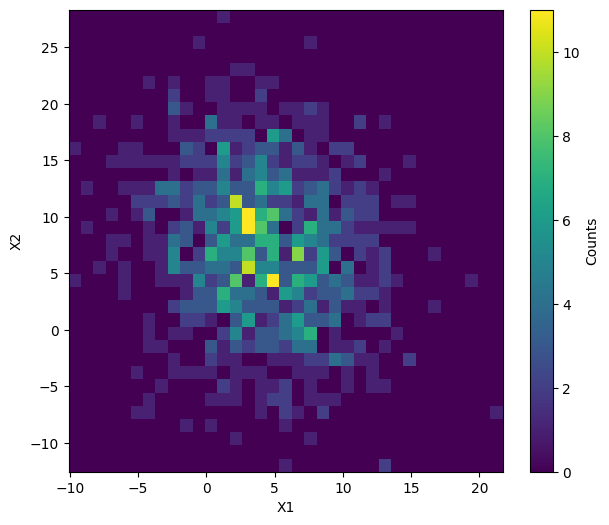

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([4, 7])
sigma = np.array([[20, -4], [-4, 40]])

def polar_box_muller(n, seed = 1):
    np.random.seed(seed)
    z = np.zeros((n, 2))
    i = 0
    while i < n:
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)
        s = u ** 2 + v ** 2
        if 0 < s < 1:
            cof = np.sqrt(-2 * np.log(s) / s)
            z[i, 0] = u * cof
            z[i, 1] = v * cof
            i += 1
    return z

z = polar_box_muller(1000)
L = np.linalg.cholesky(sigma)
x = mu + z @ L.T
sample_mean = np.mean(x, axis = 0)
sample_cov = np.cov(x, rowvar = False)

print(f"True mean: [{mu[0]}, {mu[1]}]")
print(f"Sample mean: [{sample_mean[0]:.3f}, {sample_mean[1]:.3f}]")
print(f"Error: [{abs(sample_mean[0] - mu[0]):.3f}, {abs(sample_mean[1] - mu[1]):.3f}]")
print("True covariance matrix:")
print(sigma)
print("Sample covariance matrix:")
print(np.round(sample_cov, 3))
print("Error:")
print(np.round(np.abs(sample_cov - sigma), 3))

plt.figure(figsize = (7,6))
hist = plt.hist2d(x[:,0], x[:,1], bins = 35, cmap = "viridis")
plt.colorbar(hist[3], label = "Counts")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()